Mounted at /content/drive
Device: cpu
Image size: 4372 6266
2-class DeepLabV3 model loaded.


100%|██████████| 9/9 [50:33<00:00, 337.04s/it]


Inference done
Oil pixels: 455214


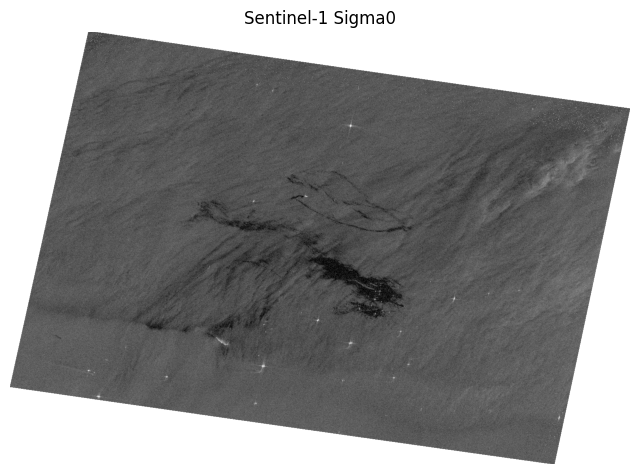

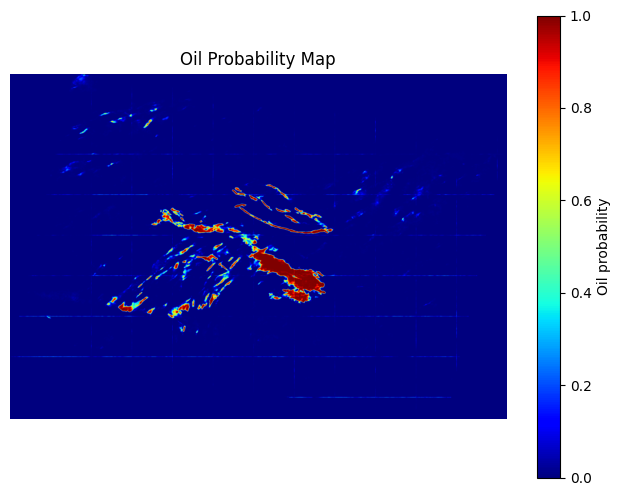

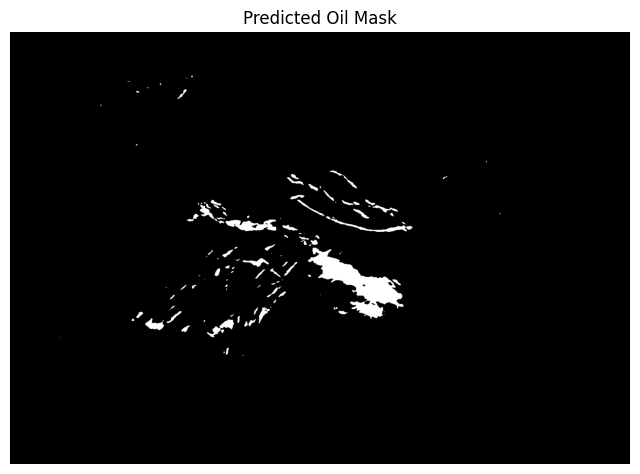

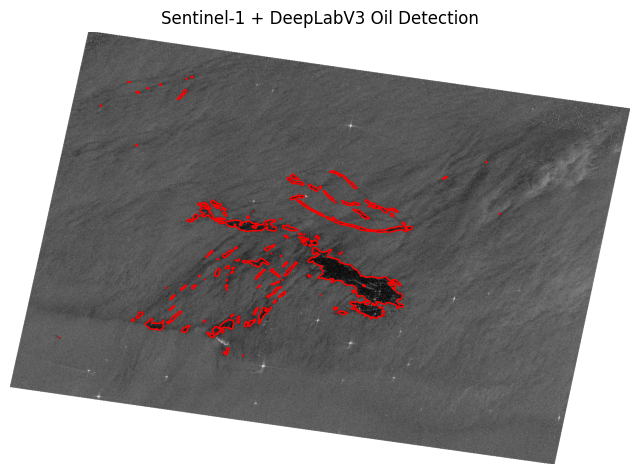

In [ ]:
# ============================================================
# inference_sentinel1.ipynb

# Apply a trained DeepLabV3-ResNet50 model to a Sentinel-1 SAR image.

# Input:
#     - MATLAB .mat file containing sigma_naught
#     - Trained DeepLabV3 model checkpoint (.pth)

# Output:
#     - Binary oil spill mask (.png)
#     - Optional .mat file containing oilMask and geolocation variables

# Classes:
#     0 = Background / Look-alike / No-oil
#     1 = Oil spill
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import torch
from scipy.io import loadmat, savemat
from PIL import Image
from torchvision.models.segmentation import deeplabv3_resnet50
import matplotlib.pyplot as plt
from tqdm import tqdm

from scipy.ndimage import uniform_filter

def make_texture_input(image_2d, window_size=7):

    image_2d = image_2d.astype(np.float32)

    local_mean = uniform_filter(image_2d, size=window_size)
    local_mean_sq = uniform_filter(image_2d**2, size=window_size)

    local_std = np.sqrt(
        np.maximum(local_mean_sq - local_mean**2, 0)
    ).astype(np.float32)

    gy, gx = np.gradient(image_2d)
    gradient_mag = np.sqrt(gx**2 + gy**2).astype(np.float32)

    local_std = (local_std - local_std.min()) / (
        local_std.max() - local_std.min() + 1e-8
    )

    gradient_mag = (gradient_mag - gradient_mag.min()) / (
        gradient_mag.max() - gradient_mag.min() + 1e-8
    )

    image_3ch = np.stack(
        [image_2d, local_std, gradient_mag],
        axis=0
    )

    return image_3ch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# File paths
# ============================================================

matFile = "/content/drive/MyDrive/SAR_AI_Oil_Spill_Detection/Yeollow_Sea_S1A_IW_GRDH_1SDV_20210501T095610.mat"

modelFile = "/content/drive/MyDrive/SAR_AI_Oil_Spill_Detection/DeeplabV3_finetuned.pth"

outMaskPath = "/content/drive/MyDrive/SAR_AI_Oil_Spill_Detection/Yeollow_Sea_20210501T095610_DeeplabV3_finetuned.png"
outMatPath = "/content/drive/MyDrive/SAR_AI_Oil_Spill_Detection/Yeollow_Sea_20210501T095610_DeeplabV3_finetuend.mat"

# ============================================================
# Load Sentinel-1 data
# ============================================================

mat = loadmat(matFile, variable_names=["sigma_naught"])

I = mat["sigma_naught"].astype(np.float32)

# xx and yy will be loaded separately after inference for result export
xx = None
yy = None

validMask = np.isfinite(I)

fill_value = np.nanmedian(I[validMask])

I_filled = I.copy()
I_filled[~validMask] = fill_value

#정규화
I_norm = np.clip(I_filled, -35, 5)
I_norm = (I_norm + 35.0) / 40.0
I_norm = np.clip(I_norm, 0, 1).astype(np.float32)

H, W = I_norm.shape
print("Image size:", H, W)

# ============================================================
# Load DeepLabV3 2-class model
# class 0 = background / non-oil / lookalike
# class 1 = oil
# ============================================================
model = deeplabv3_resnet50(
    weights=None,
    weights_backbone=None,
    num_classes=2,
    aux_loss=False
)
state = torch.load(modelFile, map_location=device)

if isinstance(state, dict) and "model_state_dict" in state:
    state = state["model_state_dict"]

model.load_state_dict(state, strict=True)

model = model.to(device)
model.eval()

print("2-class DeepLabV3 model loaded.")

# ============================================================
# Patch-based inference with overlap averaging
# ============================================================

patchSize = 1028
stride = 512
oilThreshold = 0.50

oilProbSum = np.zeros((H, W), dtype=np.float32)
countMap = np.zeros((H, W), dtype=np.float32)

with torch.no_grad():
    for r in tqdm(range(0, H, stride)):
        for c in range(0, W, stride):

            patch = I_norm[
                r:min(r + patchSize, H),
                c:min(c + patchSize, W)
            ]

            patch_valid = validMask[
                r:min(r + patchSize, H),
                c:min(c + patchSize, W)
            ]

            ph, pw = patch.shape

            # Skip patches completely outside Sentinel-1 valid area
            if np.sum(patch_valid) == 0:
                continue

            pad_value = float(np.median(patch[patch_valid]))

            padPatch = np.full(
                (patchSize, patchSize),
                pad_value,
                dtype=np.float32
            )

            padPatch[:ph, :pw] = patch

            patch_rgb = np.stack(
                [padPatch, padPatch, padPatch],
                axis=0
            ).astype(np.float32)

            patch_tensor = torch.from_numpy(
                patch_rgb
            ).unsqueeze(0).to(device)

            output = model(patch_tensor)["out"]
            prob = torch.softmax(output, dim=1)

            oil_prob = prob[0, 1, :, :].cpu().numpy()

            rr = slice(r, min(r + patchSize, H))
            cc = slice(c, min(c + patchSize, W))

            oilProbSum[rr, cc] += oil_prob[:ph, :pw]
            countMap[rr, cc] += 1.0

oilProbMap = oilProbSum / np.maximum(countMap, 1e-8)
oilMask = (oilProbMap >= oilThreshold).astype(np.uint8)

# Remove predictions outside Sentinel-1 valid image area
oilMask[~validMask] = 0
oilProbMap[~validMask] = 0

print("Inference done")

# ============================================================
# Border removal
# ============================================================

#border = 30

#oilMask[:border, :] = 0
#oilMask[-border:, :] = 0
#oilMask[:, :border] = 0
#oilMask[:, -border:] = 0

print("Oil pixels:", np.sum(oilMask))

del I_norm
del mat

import gc
gc.collect()

torch.cuda.empty_cache()

# ============================================================
# Visualization
# ============================================================

I_plot = I.copy()
I_plot[~validMask] = np.nan
I_clip = np.clip(I_plot, -35, 5)

ds = 4

plt.figure(figsize=(8, 6))
plt.imshow(I_clip[::ds, ::ds], cmap="gray")
plt.title("Sentinel-1 Sigma0")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(oilProbMap[::ds, ::ds], cmap="jet", vmin=0, vmax=1)
plt.colorbar(label="Oil probability")
plt.title("Oil Probability Map")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(oilMask[::ds, ::ds], cmap="gray")
plt.title("Predicted Oil Mask")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(I_clip[::ds, ::ds], cmap="gray")
plt.contour(oilMask[::ds, ::ds], levels=[0.5], colors="red", linewidths=1)
plt.title("Sentinel-1 + DeepLabV3 Oil Detection")
plt.axis("off")
plt.show()

In [ ]:
# ============================================================
# Save results
# ============================================================

from scipy.io import loadmat

print("Loading xx, yy ...")

geo = loadmat(
    matFile,
    variable_names=["xx","yy"]
)

xx = geo["xx"]
yy = geo["yy"]

print(xx.shape)
print(yy.shape)


Image.fromarray(oilMask * 255).save(outMaskPath)

from scipy.io import savemat

print("Saving results ...")

savemat(
    outMatPath,
    {
        "xx": xx,
        "yy": yy,
        "oilMask": oilMask.astype(np.uint8),
        "oilThreshold": oilThreshold
    },
    do_compression=True
)

print("Saved:", outMatPath)
print("Saved mat:", outMatPath)

Loading xx, yy ...
(4372, 6266)
(4372, 6266)
Saving results ...
Saved: /content/drive/MyDrive/SAR_AI_Oil_Spill_Detection/Yeollow_Sea_20210501T095610_DeeplabV3_finetuend.mat
Saved mat: /content/drive/MyDrive/SAR_AI_Oil_Spill_Detection/Yeollow_Sea_20210501T095610_DeeplabV3_finetuend.mat
